# Warehouse Network Design: Capacitated Facility Location with a Site Cap

**Problem.** A distribution business serves five regional demand clusters across the United States and is choosing which of six candidate distribution centres (DCs) to open. Opening a DC costs a fixed amount per year regardless of throughput. Once open, each unit that flows through it incurs a handling cost that depends on the site, plus an outbound freight cost that depends on the distance to the region it serves. Every DC has a throughput ceiling, and corporate policy caps the number of DCs the network may run.

Where should the DCs go, how should demand be assigned to them, and what does the site cap actually cost?

This is the **capacitated facility location problem** with a cardinality constraint. The notebook builds the model, reports the optimal network, and then runs two sensitivity analyses that are usually the point of the exercise in practice: how much a tighter site cap costs, and how the optimal network structure shifts as freight gets more expensive. 

## Formulation

**Sets.** Candidate sites $i = 1,\ldots,n$;  demand regions $j = 1,\ldots,m$.

**Parameters.**

| Symbol | Meaning |
| --- | --- |
| $O_i$ | Fixed annual cost of opening and operating DC $i$ |
| $p_i$ | Handling cost per unit flowing through DC $i$ |
| $c_{ij}$ | Outbound freight cost per unit from DC $i$ to region $j$ |
| $U_i$ | Annual throughput capacity of DC $i$ |
| $d_j$ | Annual demand of region $j$ |
| $K$ | Maximum number of DCs the network may operate |

**Decision variables.**

- $y_i \in \{0,1\}$ — 1, if DC $i$ is opened.
- $x_{ij} \ge 0$ — units shipped from DC $i$ to region $j$.

**Model.**

$$
\begin{aligned}
\min \quad & \underbrace{\sum_{i} O_i y_i}_{\text{fixed}}
          + \underbrace{\sum_{i}\sum_{j} \left(p_i + c_{ij}\right) x_{ij}}_{\text{handling + freight}} \\[4pt]
\text{s.t.}\quad
& \sum_{i} y_i \le K && \text{(site cap)} \\
& \sum_{i} x_{ij} \ge d_j && \forall j && \text{(demand)} \\
& \sum_{j} x_{ij} \le U_i y_i && \forall i && \text{(capacity)} \\
& y_i \in \{0,1\}, \quad x_{ij} \ge 0.
\end{aligned}
$$


In [1]:
import numpy as np
import pandas as pd
import gurobipy as gp
from gurobipy import GRB
import plotly.graph_objects as go
from plotly.subplots import make_subplots

## 1. Data
Six candidate DC sites and five demand regions. The figures are representative rather than drawn from a real company: annual demand of 900,000 units, fixed costs in the low hundreds of thousands, and a line-haul rate of \$0.012 per unit-mile.

In [2]:
dcs = pd.DataFrame(
    [
        ("Joliet_IL",      41.53,  -88.08, 310_000, 300_000, 1.10),
        ("Columbus_OH",    39.96,  -82.99, 250_000, 280_000, 0.95),
        ("KansasCity_MO",  39.10,  -94.58, 215_000, 260_000, 0.85),
        ("Memphis_TN",     35.15,  -90.05, 230_000, 280_000, 0.90),
        ("FortWorth_TX",   32.76,  -97.33, 240_000, 250_000, 0.95),
        ("Reno_NV",        39.53, -119.81, 275_000, 220_000, 1.15)],
    columns=["dc", "lat", "lon", "fixed_cost", "capacity", "handling"],).set_index("dc")

regions = pd.DataFrame(
    [
        ("Chicago",     41.88,  -87.63, 180_000),
        ("Newark",      40.74,  -74.17, 240_000),
        ("Atlanta",     33.75,  -84.39, 150_000),
        ("Phoenix",     33.45, -112.07, 120_000),
        ("LosAngeles",  34.05, -118.24, 210_000)],
    columns=["region", "lat", "lon", "demand"],).set_index("region")

FREIGHT_RATE = 0.012      # $ per unit per mile
SITE_CAP = 4              # maximum number of DCs the network may operate

dcs

,lat,lon,fixed_cost,capacity,handling
dc,,,,,
Joliet_IL,41.53,-88.08,310000,300000,1.10
Columbus_OH,39.96,-82.99,250000,280000,0.95
KansasCity_MO,39.10,-94.58,215000,260000,0.85
Memphis_TN,35.15,-90.05,230000,280000,0.90
FortWorth_TX,32.76,-97.33,240000,250000,0.95
Reno_NV,39.53,-119.81,275000,220000,1.15


In [3]:
def haversine_miles(lat1, lon1, lat2, lon2):
    '''Great-circle distance in miles; accepts arrays for the first pair.'''
    radius = 3958.8
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi = p2 - p1
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dlam / 2) ** 2
    return 2 * radius * np.arcsin(np.sqrt(a))

distance = pd.DataFrame(
    {r: haversine_miles(dcs.lat, dcs.lon, regions.lat[r], regions.lon[r]) for r in regions.index},
    index=dcs.index)

print("Lane distances (miles)")
distance.round(0).astype(int)

Lane distances (miles)


,Chicago,Newark,Atlanta,Phoenix,LosAngeles
dc,,,,,
Joliet_IL,34,725,574,1423,1716
Columbus_OH,276,467,436,1664,1974
KansasCity_MO,412,1085,676,1047,1354
Memphis_TN,483,946,337,1260,1600
FortWorth_TX,824,1390,750,854,1207
Reno_NV,1683,2385,1991,601,388


In [4]:
def landed_cost(rate=FREIGHT_RATE):
    '''Handling + freight per unit for every DC-to-region lane.'''
    return distance.mul(rate).add(dcs.handling, axis=0)

print("Landed cost per unit ($ = handling + freight)")
landed_cost().round(2)

Landed cost per unit ($ = handling + freight)


,Chicago,Newark,Atlanta,Phoenix,LosAngeles
dc,,,,,
Joliet_IL,1.50,9.80,7.99,18.17,21.69
Columbus_OH,4.26,6.56,6.18,20.92,24.64
KansasCity_MO,5.80,13.87,8.96,13.42,17.10
Memphis_TN,6.70,12.25,4.94,16.02,20.10
FortWorth_TX,10.84,17.63,9.95,11.19,15.44
Reno_NV,21.35,29.77,25.04,8.36,5.81


## 2. Model

In [5]:
def solve_network(site_cap=SITE_CAP, rate=FREIGHT_RATE, verbose=False):
    '''
    Solve the capacitated facility location problem.
    Returns None if infeasible (too few DCs to cover demand), otherwise a dict with the open DCs, the flow plan, and the cost breakdown.
    '''
    sites, markets = list(dcs.index), list(regions.index)
    unit_cost = landed_cost(rate)

    model = gp.Model("warehouse_network")
    model.Params.OutputFlag = int(verbose)

    x = model.addVars(sites, markets, lb=0.0, name="flow")
    y = model.addVars(sites, vtype=GRB.BINARY, name="open")

    model.setObjective(gp.quicksum(dcs.fixed_cost[i] * y[i] for i in sites)
                       + gp.quicksum(unit_cost.loc[i, j] * x[i, j] for i in sites for j in markets),
                       GRB.MINIMIZE)
    
    model.addConstr(y.sum() <= site_cap, name="site_cap")
    model.addConstrs((gp.quicksum(x[i, j] for i in sites) >= regions.demand[j] for j in markets), name="demand")
    model.addConstrs((gp.quicksum(x[i, j] for j in markets) <= dcs.capacity[i] * y[i] for i in sites), name="capacity")

    model.optimize()
    if model.Status == GRB.INFEASIBLE:
        return None
    if model.Status != GRB.OPTIMAL:
        raise RuntimeError(f"Unexpected solver status: {model.Status}")

    flows = pd.DataFrame([[x[i, j].X for j in markets] for i in sites], index=sites, columns=markets)
    flows[flows < 1e-6] = 0.0

    return {
        "site_cap": site_cap,
        "rate": rate,
        "total_cost": model.ObjVal,
        "opened": [i for i in sites if y[i].X > 0.5],
        "flows": flows,
    }

#### Solution

In [6]:
class Solution:

    def __init__(self, raw):
        self.site_cap = raw["site_cap"]
        self.rate = raw["rate"]
        self.total_cost = raw["total_cost"]
        self.opened = raw["opened"]
        self._flows = raw["flows"]
        self.fixed_cost = float(dcs.fixed_cost[self.opened].sum())
        self.handling_cost = float(self._flows.sum(axis=1).mul(dcs.handling).sum())
        self.freight_cost = float((self._flows * distance * self.rate).values.sum())
        self.dcs = self._dc_view()
        self.assignments = self._assignment_view()

    def _dc_view(self):
        throughput = self._flows.sum(axis=1)
        freight = (self._flows * distance * self.rate).sum(axis=1)
        handling = throughput * dcs.handling
        fixed = dcs.fixed_cost.where(dcs.index.isin(self.opened), 0.0)
        return pd.DataFrame({
            "status": np.where(dcs.index.isin(self.opened), "OPEN", "closed"),
            "capacity": dcs.capacity,
            "throughput": throughput.round(0),
            "utilisation": (throughput / dcs.capacity).round(3),
            "annual cost": (fixed + handling + freight).round(0)})

    def _assignment_view(self):
        s = self._flows.stack()
        s = s[s > 1e-6].rename("units").reset_index()
        s.columns = ["dc", "region", "units"]
        s["miles"] = [distance.loc[r.dc, r.region] for r in s.itertuples()]
        s["cost"] = [r.units * landed_cost(self.rate).loc[r.dc, r.region] for r in s.itertuples()]
        return s.sort_values(["region", "units"], ascending=[True, False]).reset_index(drop=True)

    def __repr__(self):
        return f"<Solution: {len(self.opened)} DCs open, ${self.total_cost:,.0f}/yr>"

def report(raw_solution):
    return Solution(raw_solution)

## 3. Optimal Network

In [7]:
base = report(solve_network())
print(f"DCs opened    : {', '.join(base.opened)}")
print(f" Fixed cost   : ${base.fixed_cost:,.0f}")
print(f" Handling cost:   ${base.handling_cost:,.0f}")
print(f" Freight cost : ${base.freight_cost:,.0f}")
print(f"Total cost    : ${base.total_cost:,.0f}/year")
base.dcs

Set parameter Username
Academic license - for non-commercial use only - expires 2027-02-13
DCs opened    : Joliet_IL, Columbus_OH, FortWorth_TX, Reno_NV
 Fixed cost   : $1,075,000
 Handling cost:   $942,500
 Freight cost : $4,563,310
Total cost    : $6,580,810/year


,status,capacity,throughput,utilisation,annual cost
Joliet_IL,OPEN,300000,290000.0,0.967,1459161.0
Columbus_OH,OPEN,280000,280000.0,1.000,2071232.0
KansasCity_MO,closed,260000,0.0,0.000,0.0
Memphis_TN,closed,280000,0.0,0.000,0.0
FortWorth_TX,OPEN,250000,110000.0,0.440,1471436.0
Reno_NV,OPEN,220000,220000.0,1.000,1578981.0


In [8]:
base.assignments.round(1)

,dc,region,units,miles,cost
0,Joliet_IL,Atlanta,110000.0,574.1,878756.4
1,Columbus_OH,Atlanta,40000.0,436.0,247271.1
2,Joliet_IL,Chicago,180000.0,33.5,270405.0
3,Reno_NV,LosAngeles,210000.0,388.5,1220403.3
4,Columbus_OH,Newark,240000.0,467.3,1573960.8
5,FortWorth_TX,Phoenix,110000.0,853.7,1231435.6
6,Reno_NV,Phoenix,10000.0,600.6,83577.5


Freight cost is roughly two thirds of total spend, which implies this is a freight-driven network. The fixed cost of a site is small next to the cost of hauling 900,000 units across the country, so the model happily pays to open sites that shorten lanes.

- **Atlanta is split.** With the site cap at four, no single open DC has the spare capacity to absorb all 150,000 units, so the region is served from two DCs. Demand splitting is optimal, it is only a problem if the business requires single sourcing, which would need the extra constraint from the plant-location.
- **Phoenix is not served from the nearest open DC alone.** Reno is closer but tight on capacity after covering Los Angeles, so part of Phoenix rides on a longer lane. This is the signature of a *capacitated* problem: nearest-DC assignment is not optimal, and any heuristic built on will miss it.

## 4. Network Map

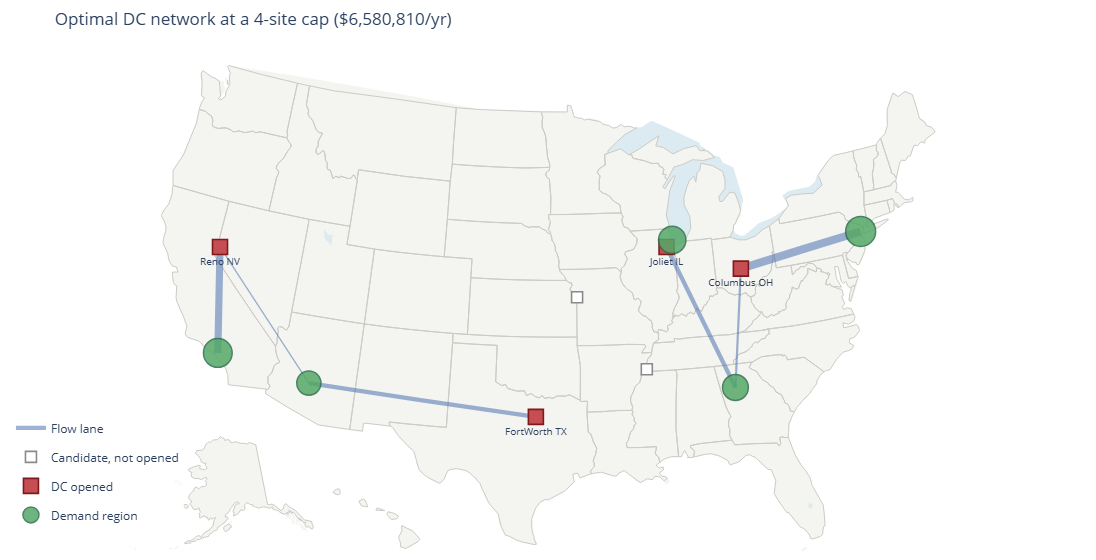

In [9]:
def network_map(sol):
    fig = go.Figure()
    max_units = sol.assignments.units.max()

    for i, row in enumerate(sol.assignments.itertuples()):
        fig.add_trace(go.Scattergeo(
            lon=[dcs.lon[row.dc], regions.lon[row.region]],
            lat=[dcs.lat[row.dc], regions.lat[row.region]],
            mode="lines",
            line=dict(width=1 + 7 * row.units / max_units, color="#4c72b0"),
            opacity=0.55, name="Flow lane", legendgroup="lanes", showlegend=(i == 0),
            hovertemplate=(f"{row.dc.replace('_', ' ')} &#8594; {row.region}"
                           f"<br>{row.units:,.0f} units/yr<extra></extra>")))

    closed = dcs[~dcs.index.isin(sol.opened)]
    fig.add_trace(go.Scattergeo(
        lon=closed.lon, lat=closed.lat, mode="markers", name="Candidate, not opened",
        marker=dict(size=11, color="white", symbol="square", line=dict(width=1.6, color="#8a8a8a")),
        text=[d.replace("_", " ") for d in closed.index],
        hovertemplate="<b>%{text}</b><br>not opened<extra></extra>"))

    opened = dcs[dcs.index.isin(sol.opened)]
    fig.add_trace(go.Scattergeo(
        lon=opened.lon, lat=opened.lat, mode="markers+text", name="DC opened",
        marker=dict(size=15, color="#c44e52", symbol="square", line=dict(width=1.6, color="#7d1a1d")),
        text=[d.replace("_", " ") for d in opened.index], textposition="bottom center",
        textfont=dict(size=10),
        customdata=np.stack([opened.index, dcs.capacity[opened.index], dcs.fixed_cost[opened.index]], axis=-1),
        hovertemplate=("<b>%{customdata[0]}</b><br>OPEN<br>capacity: %{customdata[1]:,.0f}"
                       "<br>fixed cost: $%{customdata[2]:,.0f}/yr<extra></extra>")))

    fig.add_trace(go.Scattergeo(
        lon=regions.lon, lat=regions.lat, mode="markers", name="Demand region",
        marker=dict(size=10 + 20 * np.sqrt(regions.demand / regions.demand.max()),
                    color="#55a868", opacity=0.85, line=dict(width=1.5, color="#2f6f4e")),
        customdata=np.stack([regions.index, regions.demand], axis=-1),
        hovertemplate="<b>%{customdata[0]}</b><br>%{customdata[1]:,.0f} units/yr<extra></extra>"))

    fig.update_geos(scope="usa", projection_type="albers usa", showland=True, landcolor="#f4f4f0", 
                    showlakes=True, lakecolor="#dceaf2", subunitcolor="#cccbc5", countrycolor="#9a9a94")
    fig.update_layout( title=f"Optimal DC network at a {sol.site_cap}-site cap (${sol.total_cost:,.0f}/yr)",
        height=560, margin=dict(l=0, r=0, t=50, b=0), 
        legend=dict(x=0.01, y=0.06, bgcolor="rgba(255,255,255,0.85)"))
    return fig

fig = network_map(base)
fig

## 5. Sensitivity \#1 — what does the site cap cost?
The cap on the number of DCs is a policy choice, not a physical constraint. Re-solving across values of $K$ prices that choice directly, and shows where the constraint stops binding.

In [10]:
cap_rows = []
for k in range(1, len(dcs) + 1):
    sol = solve_network(site_cap=k)
    cap_rows.append({
        "site cap": k,
        "feasible": sol is not None,
        "DCs opened": len(sol["opened"]) if sol else None,
        "network": ", ".join(d.split("_")[0] for d in sol["opened"]) if sol else "-",
        "total cost": sol["total_cost"] if sol else None,
    })
cap_study = pd.DataFrame(cap_rows).set_index("site cap")
cap_study.round(1)

,feasible,DCs opened,network,total cost
site cap,,,,
1,False,NaN,-,NaN
2,False,NaN,-,NaN
3,False,NaN,-,NaN
4,True,4.0,"Joliet, Columbus, FortWorth, Reno",6580809.6
5,True,5.0,"Joliet, Columbus, Memphis, FortWorth, Reno",6425703.1
6,True,5.0,"Joliet, Columbus, Memphis, FortWorth, Reno",6425703.1


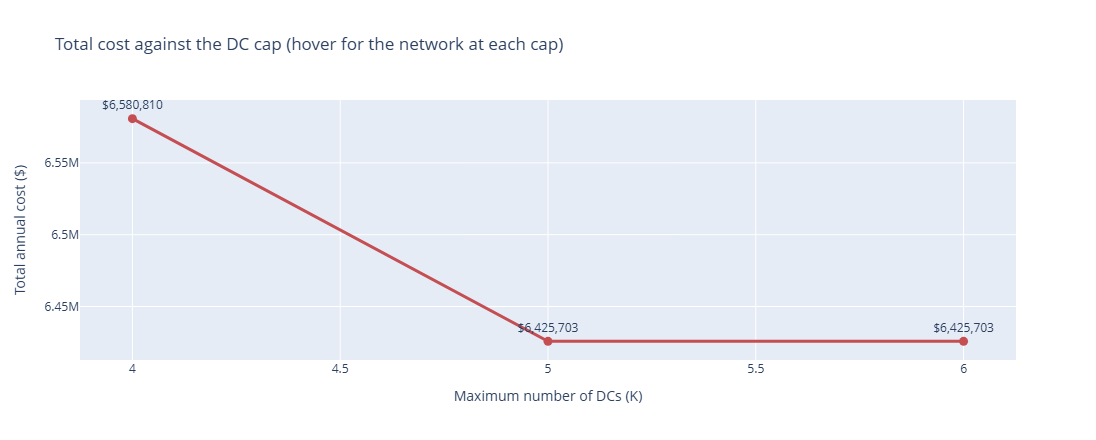

In [11]:
feasible = cap_study[cap_study.feasible]

fig = go.Figure(go.Scatter(
    x=feasible.index, y=feasible["total cost"], mode="lines+markers+text",
    text=[f"${v:,.0f}" for v in feasible["total cost"]], textposition="top center",
    line=dict(color="#c44e52", width=3), marker=dict(size=9),
    hovertemplate="cap=%{x}<br>$%{y:,.0f}<br>%{customdata}<extra></extra>",
    customdata=feasible["network"]))

fig.update_layout(
    title="Total cost against the DC cap (hover for the network at each cap)",
    xaxis_title="Maximum number of DCs (K)", yaxis_title="Total annual cost ($)", height=440, width=800)

fig.show()

Fewer than four DCs is not just expensive, it's **infeasible**, the three largest sites together can't physically cover demand, so capacity, not cost, sets the floor. Moving from four DCs to five saves about \$155,000/year: the fifth site's fixed cost is more than repaid by shorter freight. A sixth DC is never worth it, as the model declines it even when allowed, so the cap stops mattering past five.

## 6. Sensitivity \#2 — how does the network respond to freight rates?

Fuel and carrier rates move; fixed site costs are contractual and sticky. Sweeping the freight rate shows how the optimal network structure changes with the balance between them, which is the more strategically interesting question.

In [12]:
rate_rows = []
for rate in np.round(np.arange(0.002, 0.0201, 0.002), 4):
    sol = solve_network(site_cap=len(dcs), rate=rate)
    rate_rows.append({
        "rate": rate,
        "DCs opened": len(sol["opened"]),
        "network": ", ".join(d.split("_")[0] for d in sol["opened"]),
        "total cost": sol["total_cost"],
    })
rate_study = pd.DataFrame(rate_rows)
rate_study.round(3)

,rate,DCs opened,network,total cost
0,0.002,4,"Columbus, KansasCity, Memphis, Reno",2704971.220
1,0.004,4,"Joliet, Columbus, FortWorth, Reno",3538603.204
2,0.006,4,"Joliet, Columbus, FortWorth, Reno",4299154.806
3,0.008,5,"Joliet, Columbus, Memphis, FortWorth, Reno",5024968.758
4,0.010,5,"Joliet, Columbus, Memphis, FortWorth, Reno",5725335.948
5,0.012,5,"Joliet, Columbus, Memphis, FortWorth, Reno",6425703.137
6,0.014,5,"Joliet, Columbus, Memphis, FortWorth, Reno",7126070.327
7,0.016,5,"Joliet, Columbus, Memphis, FortWorth, Reno",7826437.516
8,0.018,5,"Joliet, Columbus, Memphis, FortWorth, Reno",8526804.706
9,0.020,5,"Joliet, Columbus, Memphis, FortWorth, Reno",9227171.895


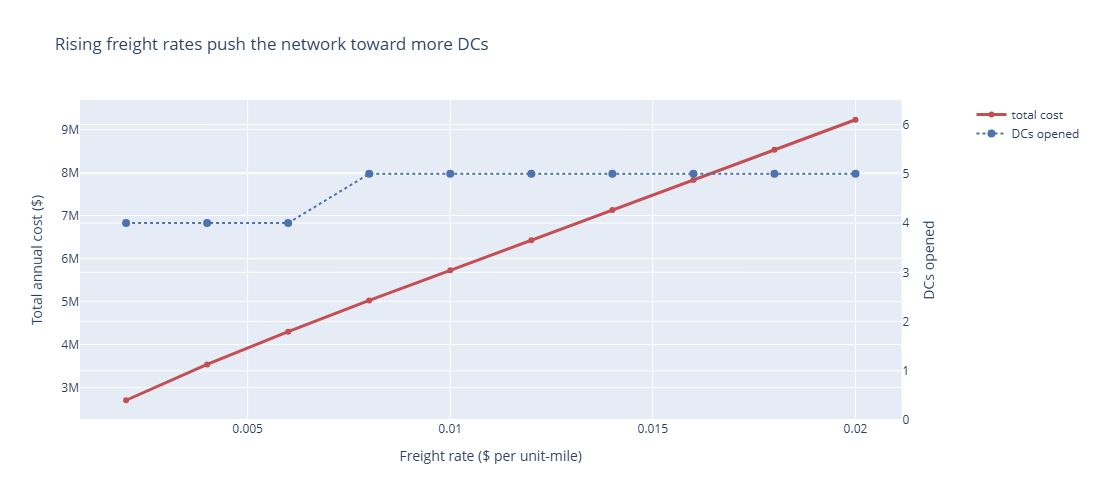

In [13]:
fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(go.Scatter(
    x=rate_study.rate, y=rate_study["total cost"], name="total cost",
    line=dict(color="#c44e52", width=3),
    hovertemplate="rate=%{x}<br>$%{y:,.0f}<extra></extra>"), secondary_y=False)

fig.add_trace(go.Scatter(
    x=rate_study.rate, y=rate_study["DCs opened"], name="DCs opened", mode="lines+markers",
    line=dict(color="#4c72b0", width=2, dash="dot"), marker=dict(size=8),
    customdata=rate_study.network,
    hovertemplate="rate=%{x}<br>%{y} DCs<br>%{customdata}<extra></extra>"), secondary_y=True)

fig.update_layout(title="Rising freight rates push the network toward more DCs", height=500, width=800)
fig.update_xaxes(title_text="Freight rate ($ per unit-mile)")
fig.update_yaxes(title_text="Total annual cost ($)", secondary_y=False)
fig.update_yaxes(title_text="DCs opened", secondary_y=True, range=[0, 6.5])
fig.show()

In [14]:
switch = rate_study["network"].ne(rate_study["network"].shift())
print("Freight rates at which the optimal footprint changes:")
rate_study[switch].round(3)

Freight rates at which the optimal footprint changes:


,rate,DCs opened,network,total cost
0,0.002,4,"Columbus, KansasCity, Memphis, Reno",2704971.220
1,0.004,4,"Joliet, Columbus, FortWorth, Reno",3538603.204
3,0.008,5,"Joliet, Columbus, Memphis, FortWorth, Reno",5024968.758


At low rates the model runs a lean network and accepts long hauls, since miles are cheap. As the rate rises, the balance flips at two points: around **`$0.003-0.004/unit-mile`** the network swaps Kansas City and Memphis for Joliet and Fort Worth (same count, different sites, the freight-optimal shape changes), and around **`$0.006-0.008/unit-mile`** a fifth DC (Memphis) becomes worth opening. In practice, that's the more useful deliverable than a single point answer: not "open these four DCs" but "open these four unless freight moves past about `$0.007`, and here's what changes if it does."

## 7. Model quality: how tight is the formulation?

A model that solves in milliseconds at this size may crawl at a few hundred sites, and the usual culprit is a weak LP relaxation. Relaxing the binaries to $[0,1]$ gives the bound the solver starts branching from; the distance between that bound and the true optimum, the **integrality gap** is the practical measure of formulation quality. 

There is also a stronger way to write the linking constraint. Instead of relying only on the aggregate capacity constraint, add a **variable upper bound** on every individual lane:

$$x_{ij} \le \min(U_i,\, d_j)\, y_i \qquad \forall \; i, j$$

These are redundant for integer $y$, they cut off no feasible integer solution, because they stop a fractionally open DC from carrying a full lane's volume while paying only a fraction of its fixed cost.

In [15]:
def lp_bound(site_cap=SITE_CAP, rate=FREIGHT_RATE, tight=False):
    '''LP relaxation bound. `tight=True` adds lane-level variable upper bounds.'''
    sites, markets = list(dcs.index), list(regions.index)
    unit_cost = landed_cost(rate)
    m = gp.Model(); m.Params.OutputFlag = 0
    
    x = m.addVars(sites, markets, lb=0.0)
    y = m.addVars(sites, lb=0.0, ub=1.0)
    
    m.setObjective(gp.quicksum(dcs.fixed_cost[i] * y[i] for i in sites)
                   + gp.quicksum(unit_cost.loc[i, j] * x[i, j] for i in sites for j in markets),
                   GRB.MINIMIZE)
    
    m.addConstr(y.sum() <= site_cap)
    m.addConstrs(gp.quicksum(x[i, j] for i in sites) >= regions.demand[j] for j in markets)
    m.addConstrs(gp.quicksum(x[i, j] for j in markets) <= dcs.capacity[i] * y[i] for i in sites)
    if tight:
        m.addConstrs(x[i, j] <= min(dcs.capacity[i], regions.demand[j]) * y[i] for i in sites for j in markets)
    m.optimize()
    return m.ObjVal

bounds = pd.DataFrame({
    "formulation": ["Plain (capacity constraint only)", "Tightened (with lane-level variable upper bounds)"],
    "LP bound": [lp_bound(), lp_bound(tight=True)]})
bounds["Integer optimum"] = base.total_cost
bounds["Integrality gap"] = (bounds["Integer optimum"] - bounds["LP bound"]) / bounds["Integer optimum"]
bounds.style.format({"LP bound": "${:,.0f}", "Integer optimum": "${:,.0f}", "Integrality gap": "{:.2%}"})

,formulation,LP bound,Integer optimum,Integrality gap
0,Plain (capacity constraint only),"$6,024,803","$6,580,810",8.45%
1,Tightened (with lane-level variable upper bounds),"$6,541,861","$6,580,810",0.59%


The plain formulation leaves an integrality gap of about **8.4%**, which is respectable but not tight, the relaxation buys partial sites to dodge fixed costs. Adding the lane-level variable upper bounds closes it to roughly **0.6%**, so the solver starts branching from a bound that very nearly proves the answer on its own.

The trade-off is size: the disaggregated version adds $n \times m$ constraints, which here is 30 extra rows and effectively free, but on a thousand-site model is a real memory cost. The usual practice is to add them lazily or let the solver generate them as cuts. Either way the point stands on models like this, how the linking constraint is written matters more for runtime than any solver parameter.

## 8. Conclusions

- **The network is freight-dominated.** Outbound freight is around two-thirds of annual spend. Fixed site costs are the smallest component, which is why the model opens sites readily, every additional DC is buying miles back.
- **Capacity, not cost, sets the minimum footprint.** Three DCs cannot physically cover all of the demand. The first genuine economic choice is between four and five sites; the fifth is worth roughly `$155,000` a year, and a sixth is worth nothing, so the cap stops binding at five.
- **Nearest-DC assignment would be wrong.** Capacity limits split Atlanta across two DCs and push part of Phoenix onto a farther site because the closer one is full. Any heuristic that assigns each region to its nearest open DC does worse than the MIP.
- **The recommendation is rate-dependent.** The optimal footprint shifts from four DCs to five as the line-haul rate rises past roughly `$0.006` per unit-mile. In practice that is the real deliverable, not "open these four DCs" but "open these four unless freight moves above this rate, and here is the site to add when it does".
- **Formulation strength is a design decision.** Lane-level variable upper bounds cut the integrality gap from `8.4%` to `0.6%` without changing the optimal solution at all.

Natural extensions to this model include multi-echelon flows through cross-docks, a service-level constraint capping delivery distance or transit time, single-sourcing per region, inbound freight from suppliers, and a multi-period version where sites open progressively over a horizon.